## Voting Classifiers

In [1]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

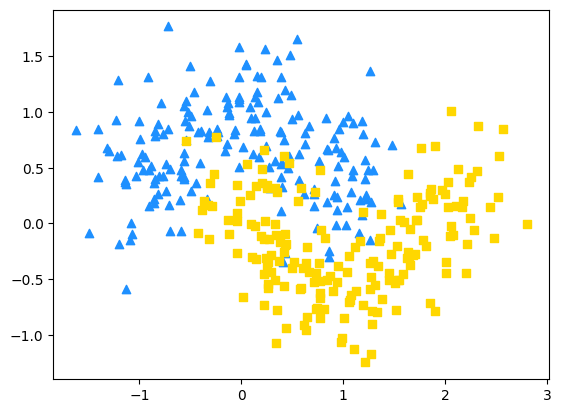

In [2]:
import matplotlib.pyplot as plt

plt.scatter(X_train[:, 0][y_train==0], X_train[:, 1][y_train==0], color="dodgerblue", marker="^")
plt.scatter(X_train[:, 0][y_train==1], X_train[:, 1][y_train==1], color="gold", marker="s")

In [3]:
voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('svc', SVC(random_state=42))
    ]
)
voting_clf.fit(X_train, y_train)

,estimators,"[('lr', ...), ('rf', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [4]:
voting_clf.named_estimators_

{'lr': LogisticRegression(random_state=42),
 'rf': RandomForestClassifier(random_state=42),
 'svc': SVC(random_state=42)}

In [5]:
for name, clf in voting_clf.named_estimators_.items():
    print(name, "=", clf.score(X_test, y_test))

lr = 0.864
rf = 0.896
svc = 0.896


In [6]:
voting_clf.predict(X_test[:1])

array([1])

In [7]:
[clf.predict(X_test[:20]) for clf in voting_clf.estimators_]

[array([1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0]),
 array([1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0]),
 array([0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0])]

In [8]:
voting_clf.score(X_test, y_test)

0.912

In [9]:
voting_clf.voting = "soft"
voting_clf.named_estimators["svc"].probability = True
voting_clf.fit(X_train, y_train)
voting_clf.score(X_test, y_test)

0.92

## Bagging and Pasting

### Bagging and Pasting in Scikit-Learn

In [10]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(
    DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=100,
    n_jobs=-1,
    random_state=42
    )
bag_clf.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,n_estimators,500
,max_samples,100
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,-1
,random_state,42
,verbose,0


### Out of Bag Evaluation

In [11]:
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(),
    n_estimators=500,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)

bag_clf.fit(X_train, y_train)
bag_clf.oob_score_

0.896

In [12]:
from sklearn.metrics import accuracy_score

y_pred = bag_clf.predict(X_test)
accuracy_score(y_pred, y_test)

0.92

## Random Forests

In [13]:
from sklearn.ensemble import RandomForestClassifier

rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16, n_jobs=-1, random_state=42)
rnd_clf.fit(X_train, y_train)

y_pred_rf = rnd_clf.predict(X_test)
accuracy_score(y_pred_rf, y_test)

0.912

In [14]:
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(
        max_features="sqrt",
        max_leaf_nodes=16
    ),
    n_estimators=500,
    n_jobs=-1,
    random_state=42
)

bag_clf.fit(X_train, y_train)
y_pred_bag = bag_clf.predict(X_test)
accuracy_score(y_pred_bag, y_test)

0.912

### Feature Importance

In [15]:
from sklearn.datasets import load_iris

iris= load_iris(as_frame=True)
rnd_clf = RandomForestClassifier(n_estimators=500, random_state=42)
rnd_clf.fit(iris.data, iris.target)

for score, name in zip(rnd_clf.feature_importances_, iris.data.columns):
    print(round(score, 2), name)

0.11 sepal length (cm)
0.02 sepal width (cm)
0.44 petal length (cm)
0.42 petal width (cm)


In [16]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784", version=1)

X = mnist.data
y = mnist.target

X_train, X_test, y_train, y_test = train_test_split(X, y)

print(X_train.shape, y_train.shape)

(52500, 784) (52500,)


In [17]:
rnd_clf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rnd_clf.fit(X_train, y_train)

y_pred = rnd_clf.predict(X_test)
accuracy_score(y_pred, y_test)

0.9700571428571428

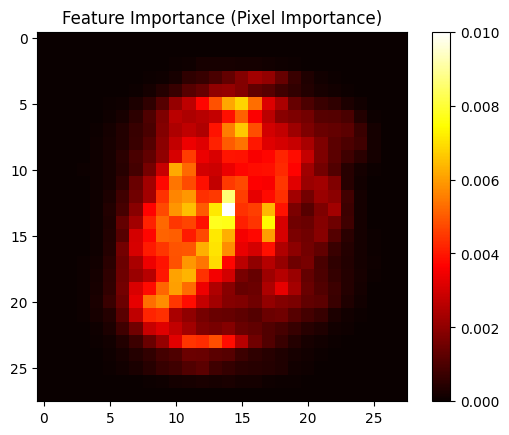

In [18]:
import matplotlib.pyplot as plt

importances = rnd_clf.feature_importances_

importance_grid = importances.reshape(28, 28)

plt.imshow(importance_grid, cmap="hot")
plt.colorbar()
plt.title("Feature Importance (Pixel Importance)")
plt.show()

## Boosting

### Adaboost

In [19]:
X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [20]:
from sklearn.ensemble import AdaBoostClassifier

ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1),
    n_estimators=20,
    learning_rate=0.5, 
    random_state=42,
)

ada_clf.fit(X_train, y_train)

,estimator,DecisionTreeC...r(max_depth=1)
,n_estimators,20
,learning_rate,0.5
,algorithm,'deprecated'
,random_state,42
,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [21]:
y_pred = ada_clf.predict(X_test)
accuracy_score(y_pred, y_test)

0.88

## Gradient Boosting

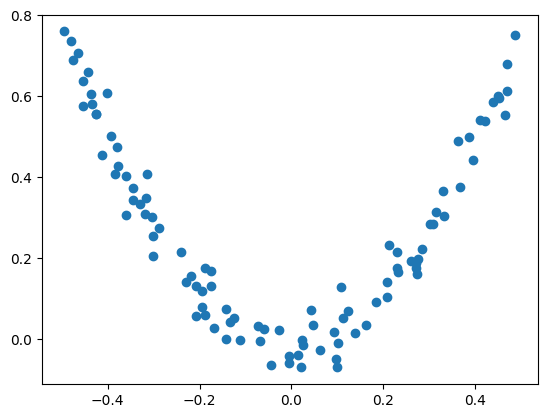

In [22]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

np.random.seed(42)

X = np.random.rand(100, 1) - 0.5
y = 3 * X[:, 0] ** 2 + 0.05 * np.random.randn(100)

plt.scatter(X, y)

In [23]:
tree_reg1 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg1.fit(X, y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [24]:
y2 = y - tree_reg1.predict(X)
tree_reg2 = DecisionTreeRegressor(max_depth=2, random_state=43)
tree_reg2.fit(X, y2)

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,43
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [25]:
y3 = y2 - tree_reg2.predict(X)
tree_reg3 = DecisionTreeRegressor(max_depth=2, random_state=44)
tree_reg3.fit(X, y3)

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,44
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [26]:
X_new = np.array([[-0.4], [0], [0.5]])
sum(tree.predict(X_new) for tree in (tree_reg1, tree_reg2, tree_reg3))

array([0.49484029, 0.04021166, 0.75026781])

Residuals at each steps

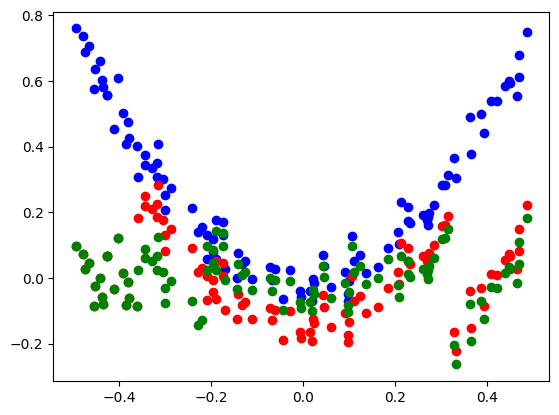

In [27]:
plt.scatter(X, y, color="blue")
plt.scatter(X, y2, color="red")
plt.scatter(X, y3, color="green")

Predictions of each estimator

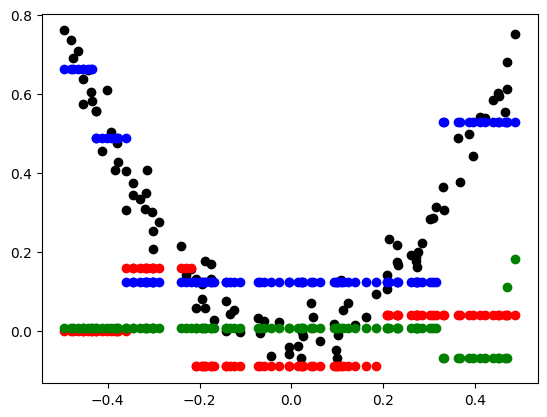

In [28]:
plt.scatter(X, y, color="black")
plt.scatter(X, tree_reg1.predict(X), color="blue")
plt.scatter(X, tree_reg2.predict(X), color="red")
plt.scatter(X, tree_reg3.predict(X), color="green")

Prediction of final model

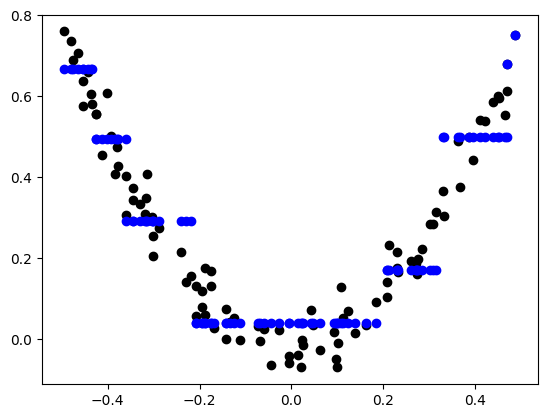

In [29]:
y_pred = tree_reg1.predict(X) + tree_reg2.predict(X) + tree_reg3.predict(X) 
plt.scatter(X, y, color="black")
plt.scatter(X, y_pred, color="blue")

In [30]:
from sklearn.ensemble import GradientBoostingRegressor

gbrt = GradientBoostingRegressor(
    max_depth=2,
    n_estimators=3,
    learning_rate=1,
    random_state=42
)
gbrt.fit(X, y)

,loss,'squared_error'
,learning_rate,1
,n_estimators,3
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,2
,min_impurity_decrease,0.0
,init,None


In [31]:
gbrt_best = GradientBoostingRegressor(
    max_depth=2,
    n_estimators=500,
    learning_rate=0.05,
    n_iter_no_change=10,
    random_state=42
)
gbrt_best.fit(X, y)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,500
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,2
,min_impurity_decrease,0.0
,init,None


In [32]:
gbrt_best.n_estimators_

92

### Histogram Based Gradient Boosting

In [36]:
from sklearn.datasets import fetch_openml

titanic = fetch_openml(name="titanic", version=1, as_frame=True)
X = titanic.data
y = titanic.target

list(X)

['pclass',
 'name',
 'sex',
 'age',
 'sibsp',
 'parch',
 'ticket',
 'fare',
 'cabin',
 'embarked',
 'boat',
 'body',
 'home.dest']

In [37]:
drop_columns = ["name", "ticket", "cabin", "home.dest", "boat"]
X = X.drop(columns=drop_columns)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [39]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder

hgb_clf = make_pipeline(
    make_column_transformer(
        (OrdinalEncoder(), ["pclass", "sex", "embarked"]),
        remainder="passthrough"
    ),
    HistGradientBoostingClassifier(categorical_features=[0, 1, 2], random_state=42)
)

hgb_clf.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('histgradientboostingclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ordinalencoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [40]:
y_pred = hgb_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.8140243902439024